<a href="https://colab.research.google.com/github/panji438/Credit-Default-Prediction/blob/main/Credit_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Prediksi Modern dan Machine Learning
## Experiment Challenge: Credit Default Prediction

**Nama:** Panji Mahesa  
**NIM:** 2404220010  
**Mata Kuliah:** Prediksi Modern dan Machine Learning  

### Dataset
Default of Credit Card Clients Dataset.

Sumber:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

### Rancangan Evaluasi
- Train-test split: 80% training dan 20% testing.
- Stratified 5-fold Cross Validation pada training set.
- Metrik utama: F1-score untuk kelas gagal bayar (1).
- Metrik pendukung: Accuracy, Precision, dan Recall.
- Pemilihan model dan hyperparameter menggunakan hasil cross-validation.
- Test set digunakan untuk pelaporan evaluasi, bukan untuk menentukan
  pengaturan model.

In [2]:
# SEL 1 — Import library

import io
import json
import platform
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from google.colab import files
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    ParameterGrid
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Library berhasil diimpor.")
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Library berhasil diimpor.
Python: 3.13.16
pandas: 2.2.3
scikit-learn: 1.6.1


In [5]:
# SEL 2 — Membaca dataset

df = pd.read_csv("UCI_Credit_Card.csv")

df.columns = df.columns.str.strip()

print("Dataset berhasil dibaca.")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

display(df.head())

Dataset berhasil dibaca.
Jumlah baris: 30000
Jumlah kolom: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Experiment 0 — Data Understanding dan Data Preparation

Tahap ini memeriksa dimensi data, struktur variabel, missing value,
duplikasi, nilai yang perlu diperhatikan, dan distribusi target.
Hasil pemeriksaan digunakan untuk menentukan persiapan data.

In [11]:
# SEL 3 — Struktur dan statistik deskriptif

TARGET = "default.payment.next.month"

kolom_diharapkan = (
    ["ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
    + ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
    + [TARGET]
)

assert set(df.columns) == set(kolom_diharapkan), (
    "Kolom dataset berbeda. Periksa file yang diunggah."
)

print("STRUKTUR DATA")
df.info()

print("\nSTATISTIK DESKRIPTIF")
display(df.describe().T)

STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2        

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [12]:
# SEL 4 — Missing value dan duplikasi

print("MISSING VALUE")
display(
    df.isna().sum().to_frame("Jumlah Missing")
)

print("Duplikat lengkap:", df.duplicated().sum())
print("ID berulang:", df["ID"].duplicated().sum())

duplikat_tanpa_id = df.drop(columns="ID").duplicated().sum()
print("Baris identik tanpa ID:", duplikat_tanpa_id)

assert df.isna().sum().sum() == 0, (
    "Ada missing value yang perlu ditangani."
)

assert df["ID"].is_unique, (
    "Ada ID berulang yang perlu diperiksa."
)

assert all(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns), (
    "Ada kolom non-numerik yang perlu diperiksa."
)

assert np.isfinite(df.to_numpy(dtype=float)).all(), (
    "Ada nilai tak hingga."
)

assert set(df[TARGET].unique()) == {0, 1}, (
    "Target harus berisi kelas 0 dan 1."
)

print("\nPemeriksaan dasar berhasil.")

MISSING VALUE


,Jumlah Missing
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


Duplikat lengkap: 0
ID berulang: 0
Baris identik tanpa ID: 35

Pemeriksaan dasar berhasil.


In [13]:
# SEL 5 — Pemeriksaan kategori dan rentang nilai

kolom_status = [
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
]

for kolom in ["SEX", "EDUCATION", "MARRIAGE"] + kolom_status:
    print(f"\nDistribusi {kolom}:")
    print(df[kolom].value_counts().sort_index())

kolom_uang = (
    ["LIMIT_BAL"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
)

print("\nRENTANG NILAI")
display(df[kolom_uang + ["AGE"]].agg(["min", "max"]).T)

print("\nJUMLAH NILAI NEGATIF PADA VARIABEL UANG")
display(
    (df[kolom_uang] < 0)
    .sum()
    .to_frame("Jumlah Nilai Negatif")
)


Distribusi SEX:
SEX
1    11888
2    18112
Name: count, dtype: int64

Distribusi EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Distribusi MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Distribusi PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Distribusi PAY_2:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Distribusi PAY_3:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

Distribusi PAY_4:
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58


,min,max
LIMIT_BAL,10000.0,1000000.0
BILL_AMT1,-165580.0,964511.0
BILL_AMT2,-69777.0,983931.0
BILL_AMT3,-157264.0,1664089.0
BILL_AMT4,-170000.0,891586.0
BILL_AMT5,-81334.0,927171.0
BILL_AMT6,-339603.0,961664.0
PAY_AMT1,0.0,873552.0
PAY_AMT2,0.0,1684259.0
PAY_AMT3,0.0,896040.0



JUMLAH NILAI NEGATIF PADA VARIABEL UANG


,Jumlah Nilai Negatif
LIMIT_BAL,0
BILL_AMT1,590
BILL_AMT2,669
BILL_AMT3,655
BILL_AMT4,675
BILL_AMT5,655
BILL_AMT6,688
PAY_AMT1,0
PAY_AMT2,0
PAY_AMT3,0


,Jumlah,Persentase
Target,,
0,23364,77.88
1,6636,22.12


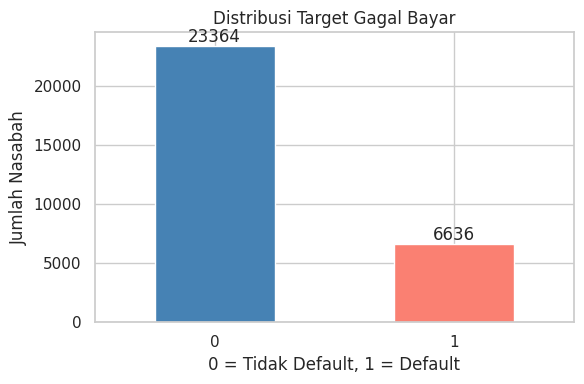

In [14]:
# SEL 6 — Distribusi target

distribusi_target = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .to_frame("Jumlah")
)

distribusi_target["Persentase"] = (
    distribusi_target["Jumlah"] / len(df) * 100
)

display(distribusi_target.round(2))

ax = distribusi_target["Jumlah"].plot(
    kind="bar",
    figsize=(6, 4),
    color=["steelblue", "salmon"]
)

ax.set_title("Distribusi Target Gagal Bayar")
ax.set_xlabel("0 = Tidak Default, 1 = Default")
ax.set_ylabel("Jumlah Nasabah")
ax.tick_params(axis="x", rotation=0)

for posisi, jumlah in enumerate(distribusi_target["Jumlah"]):
    ax.text(posisi, jumlah, str(jumlah), ha="center", va="bottom")

plt.tight_layout()
plt.show()

- Dataset memiliki 30.000 observasi dan 25 variabel.
- Tidak ditemukan missing value maupun ID berulang.
- Tidak ditemukan duplikat lengkap, tetapi terdapat 35 baris identik setelah ID dikeluarkan.
- Observasi dengan ID berbeda dipertahankan karena belum ada bukti bahwa observasi tersebut merupakan kesalahan pencatatan.
- Target terdiri dari 77,88% tidak gagal bayar dan 22,12% gagal bayar.
- Tidak dilakukan imputasi karena tidak terdapat missing value.
- Nilai kategori dan tagihan negatif dipertahankan; tidak dilakukan penghapusan otomatis.
- ID dikeluarkan dari predictor.
- Scaling dan encoding akan diuji pada Experiment 2.

In [15]:
# SEL 7 — Predictor, target, dan train-test split

X = df.drop(columns=["ID", TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Jumlah predictor:", X.shape[1])
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

proporsi = pd.DataFrame({
    "Seluruh Data": y.value_counts(normalize=True).sort_index(),
    "Training": y_train.value_counts(normalize=True).sort_index(),
    "Testing": y_test.value_counts(normalize=True).sort_index()
}) * 100

print("\nPROPORSI KELAS (%)")
display(proporsi.round(2))

assert "ID" not in X.columns
assert TARGET not in X.columns
assert set(X_train.index).isdisjoint(X_test.index)

Jumlah predictor: 23
X_train: (24000, 23)
X_test : (6000, 23)
y_train: (24000,)
y_test : (6000,)

PROPORSI KELAS (%)


,Seluruh Data,Training,Testing
default.payment.next.month,,,
0,77.88,77.88,77.88
1,22.12,22.12,22.12


80% data digunakan untuk training dan 20% untuk testing, dengan stratifikasi untuk menjaga proporsi kelas.

In [16]:
# SEL 8 — Preprocessing

kolom_kategori = ["SEX", "EDUCATION", "MARRIAGE"]

kolom_numerik = [
    kolom for kolom in X.columns
    if kolom not in kolom_kategori
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numerik", StandardScaler(), kolom_numerik),
        (
            "kategori",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            kolom_kategori
        )
    ],
    remainder="drop"
)

def buat_pipeline(model):
    return Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", model)
    ])

print("Kategori:", kolom_kategori)
print("Jumlah fitur numerik:", len(kolom_numerik))
print("Preprocessing sudah didefinisikan, belum dilatih.")

Kategori: ['SEX', 'EDUCATION', 'MARRIAGE']
Jumlah fitur numerik: 20
Preprocessing sudah didefinisikan, belum dilatih.


StandardScaler: menyetarakan skala fitur numerik.

OneHotEncoder: mengubah kategori menjadi kolom indikator.

Pipeline: menggabungkan preprocessing dengan model.

In [17]:
# SEL 9 — Cross-validation dan fungsi evaluasi

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scorer_f1 = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

hasil = {}
model_terlatih = {}

def evaluasi_model(
    kode,
    eksperimen,
    nama_model,
    estimator,
    cv_scores=None,
    sudah_fit=False,
    sumber_cv="5-fold CV"
):
    print(f"Menjalankan {eksperimen}: {nama_model}")

    if cv_scores is None:
        cv_scores = cross_val_score(
            estimator,
            X_train,
            y_train,
            cv=cv,
            scoring=scorer_f1,
            n_jobs=-1,
            error_score="raise"
        )

    cv_scores = np.asarray(cv_scores, dtype=float)

    if sudah_fit:
        fitted = estimator
    else:
        fitted = clone(estimator)
        fitted.fit(X_train, y_train)

    prediksi = fitted.predict(X_test)

    hasil[kode] = {
        "Experiment": eksperimen,
        "Model": nama_model,
        "CV F1": cv_scores.mean(),
        "CV F1 SD": cv_scores.std(ddof=0),
        "Test Accuracy": accuracy_score(y_test, prediksi),
        "Test Precision": precision_score(
            y_test, prediksi, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, prediksi, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, prediksi, zero_division=0
        ),
        "Sumber CV": sumber_cv
    }

    model_terlatih[kode] = fitted

    print("F1 tiap fold:", np.round(cv_scores, 4))
    display(pd.DataFrame([hasil[kode]]).round(4))

    return fitted

print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


## Experiment 1 — Logistic Regression Baseline
Tahap ini, model menerima fitur asli tanpa scaling dan tanpa one-hot encoding. Kode kategori masih diperlakukan sebagai angka pada baseline.

In [18]:
# SEL 10 — Baseline Logistic Regression

baseline = Pipeline([
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            max_iter=10000,
            random_state=SEED
        )
    )
])

model_baseline = evaluasi_model(
    kode="E1",
    eksperimen="1",
    nama_model="Logistic Regression Baseline",
    estimator=baseline
)

Menjalankan 1: Logistic Regression Baseline
F1 tiap fold: [0. 0. 0. 0. 0.]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,1,Logistic Regression Baseline,0.0,0.0,0.7788,0.0,0.0,0.0,5-fold CV


In [19]:
# Memeriksa kelas yang diprediksi baseline
prediksi_baseline = model_terlatih["E1"].predict(X_test)

print("Jumlah prediksi setiap kelas:")
print(
    pd.Series(prediksi_baseline)
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("Kelas")
    .to_frame("Jumlah Prediksi")
)

Jumlah prediksi setiap kelas:
       Jumlah Prediksi
Kelas                 
0                 6000
1                    0


**Interpretasi Experiment 1**

Baseline memperoleh accuracy 77,88%, tetapi precision, recall, F1-score, dan CV F1 semuanya bernilai 0. Model memprediksi seluruh 6.000 nasabah sebagai tidak gagal bayar, sehingga belum mampu mendeteksi kelas gagal bayar. Experiment 2 akan menguji apakah scaling dan encoding dapat meningkatkan performanya.

## Experiment 2 — Logistic Regression dengan Preprocessing

Pada eksperimen ini, fitur numerik diproses menggunakan StandardScaler, sedangkan SEX, EDUCATION, dan MARRIAGE menggunakan OneHotEncoder. Model, pembagian data, dan fold evaluasi tetap sama dengan baseline untuk menguji pengaruh gabungan scaling dan encoding terhadap performa.

In [20]:
# SEL 11 — Logistic Regression dengan preprocessing

lr_preprocessing = buat_pipeline(
    LogisticRegression(
        solver="liblinear",
        max_iter=10000,
        random_state=SEED
    )
)

evaluasi_model(
    kode="E2",
    eksperimen="2",
    nama_model="Logistic Regression + Preprocessing",
    estimator=lr_preprocessing
)

print("\nPERBANDINGAN EXPERIMENT 1 DAN 2")
display(
    pd.DataFrame([hasil["E1"], hasil["E2"]]).round(4)
)

print(
    "Perubahan CV F1:",
    round(hasil["E2"]["CV F1"] - hasil["E1"]["CV F1"], 4)
)

print(
    "Perubahan Test F1:",
    round(hasil["E2"]["Test F1"] - hasil["E1"]["Test F1"], 4)
)

Menjalankan 2: Logistic Regression + Preprocessing
F1 tiap fold: [0.3689 0.3702 0.3838 0.3669 0.3385]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,2,Logistic Regression + Preprocessing,0.3657,0.0148,0.8088,0.6923,0.2442,0.361,5-fold CV



PERBANDINGAN EXPERIMENT 1 DAN 2


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,1,Logistic Regression Baseline,0.0000,0.0000,0.7788,0.0000,0.0000,0.000,5-fold CV
1,2,Logistic Regression + Preprocessing,0.3657,0.0148,0.8088,0.6923,0.2442,0.361,5-fold CV


Perubahan CV F1: 0.3657
Perubahan Test F1: 0.361


**Interpretasi Experiment 2**

Setelah scaling dan encoding, CV F1 meningkat dari 0 menjadi 0,3657 dan Test F1 menjadi 0,3610. Accuracy juga meningkat dari 77,88% menjadi 80,88%, dengan precision 69,23% dan recall 24,42%. Preprocessing memperbaiki performa model, tetapi sebagian besar nasabah gagal bayar masih belum berhasil terdeteksi karena recall masih rendah.

## Experiment 3 — Model Comparison

Eksperimen ini membandingkan Logistic Regression, Decision Tree, dan Random Forest menggunakan preprocessing, pembagian data, serta 5-fold cross-validation yang sama. Hasil Logistic Regression dari Experiment 2 digunakan kembali karena konfigurasinya identik. Model dengan rata-rata CV F1 tertinggi dipilih untuk hyperparameter tuning.

In [21]:
# SEL 12 — Model comparison

model_kandidat = {
    "Logistic Regression": lr_preprocessing,

    "Decision Tree": buat_pipeline(
        DecisionTreeClassifier(
            random_state=SEED
        )
    ),

    "Random Forest": buat_pipeline(
        RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=1
        )
    )
}

# Menggunakan kembali hasil Logistic Regression dari Experiment 2
hasil["E3_LR"] = {
    **hasil["E2"],
    "Experiment": "3",
    "Model": "Logistic Regression"
}

model_terlatih["E3_LR"] = model_terlatih["E2"]

# Evaluasi Decision Tree
evaluasi_model(
    kode="E3_DT",
    eksperimen="3",
    nama_model="Decision Tree",
    estimator=model_kandidat["Decision Tree"]
)

# Evaluasi Random Forest
evaluasi_model(
    kode="E3_RF",
    eksperimen="3",
    nama_model="Random Forest",
    estimator=model_kandidat["Random Forest"]
)

# Tabel perbandingan ketiga model
kode_e3 = ["E3_LR", "E3_DT", "E3_RF"]

tabel_e3 = pd.DataFrame(
    [hasil[kode] for kode in kode_e3],
    index=kode_e3
).sort_values(
    "CV F1",
    ascending=False,
    kind="stable"
)

print("\nPERBANDINGAN EXPERIMENT 3")
display(tabel_e3.round(4))

# Memilih model berdasarkan CV F1, bukan skor test
kode_terbaik_e3 = tabel_e3.index[0]
nama_terbaik_e3 = hasil[kode_terbaik_e3]["Model"]

print("Model terbaik berdasarkan CV F1:", nama_terbaik_e3)
print(
    "CV F1:",
    round(hasil[kode_terbaik_e3]["CV F1"], 4)
)

Menjalankan 3: Decision Tree
F1 tiap fold: [0.4124 0.3935 0.4103 0.3854 0.3902]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,3,Decision Tree,0.3984,0.0109,0.7185,0.3731,0.4009,0.3865,5-fold CV


Menjalankan 3: Random Forest
F1 tiap fold: [0.4765 0.4856 0.4753 0.4653 0.4517]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,3,Random Forest,0.4709,0.0116,0.8105,0.6243,0.3595,0.4562,5-fold CV



PERBANDINGAN EXPERIMENT 3


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
E3_RF,3,Random Forest,0.4709,0.0116,0.8105,0.6243,0.3595,0.4562,5-fold CV
E3_DT,3,Decision Tree,0.3984,0.0109,0.7185,0.3731,0.4009,0.3865,5-fold CV
E3_LR,3,Logistic Regression,0.3657,0.0148,0.8088,0.6923,0.2442,0.3610,5-fold CV


Model terbaik berdasarkan CV F1: Random Forest
CV F1: 0.4709


**Interpretasi Experiment 3**

Random Forest memperoleh CV F1 tertinggi sebesar 0,4709 dan Test F1 sebesar 0,4562, mengungguli Decision Tree dan Logistic Regression. Accuracy mencapai 81,05%, dengan precision 62,43% dan recall 35,95%. Berdasarkan CV F1 sebagai metrik utama, Random Forest dipilih untuk hyperparameter tuning pada Experiment 4.

## Experiment 4 — Hyperparameter Tuning

Random Forest sebagai model terbaik Experiment 3 dituning menggunakan GridSearchCV dengan 5-fold cross-validation. Parameter yang diuji meliputi jumlah pohon, kedalaman maksimum, minimum sampel pada daun, dan bobot kelas. Kombinasi terbaik dipilih berdasarkan CV F1, kemudian dievaluasi pada test set dan dibandingkan dengan model sebelum tuning.

In [22]:
# SEL 13 — Hyperparameter tuning Random Forest

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [1, 5],
    "model__class_weight": [None, "balanced"]
}

print("Model yang dituning:", nama_terbaik_e3)
print("Parameter yang diuji:", param_grid)

jumlah_kombinasi = len(list(ParameterGrid(param_grid)))

print("Jumlah kombinasi:", jumlah_kombinasi)
print("Jumlah pelatihan CV:", jumlah_kombinasi * 5)

grid_search = GridSearchCV(
    estimator=clone(model_kandidat[nama_terbaik_e3]),
    param_grid=param_grid,
    scoring=scorer_f1,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise"
)

grid_search.fit(X_train, y_train)

print("\nTUNING SELESAI")
print("Parameter terbaik:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))

Model yang dituning: Random Forest
Parameter yang diuji: {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10], 'model__min_samples_leaf': [1, 5], 'model__class_weight': [None, 'balanced']}
Jumlah kombinasi: 16
Jumlah pelatihan CV: 80
Fitting 5 folds for each of 16 candidates, totalling 80 fits

TUNING SELESAI
Parameter terbaik: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV F1: 0.5444


In [23]:
# SEL 14 — Evaluasi hasil tuning

hasil_grid = pd.DataFrame(grid_search.cv_results_)

print("HASIL PENCARIAN HYPERPARAMETER")
display(
    hasil_grid[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .round(4)
)

# Mengambil skor setiap fold dari kombinasi terbaik
indeks_terbaik = grid_search.best_index_

cv_tuned = np.array([
    grid_search.cv_results_[f"split{i}_test_score"][indeks_terbaik]
    for i in range(5)
])

# Model terbaik sudah dilatih ulang oleh GridSearchCV
evaluasi_model(
    kode="E4",
    eksperimen="4",
    nama_model=f"{nama_terbaik_e3} + Tuning",
    estimator=grid_search.best_estimator_,
    cv_scores=cv_tuned,
    sudah_fit=True,
    sumber_cv="Best CV dari GridSearchCV"
)

print("\nSEBELUM DAN SESUDAH TUNING")
display(
    pd.DataFrame([
        hasil[kode_terbaik_e3],
        hasil["E4"]
    ]).round(4)
)

for metrik in ["CV F1", "Test F1"]:
    perubahan = (
        hasil["E4"][metrik] - hasil[kode_terbaik_e3][metrik]
    )
    print(f"Perubahan {metrik}: {perubahan:.4f}")

HASIL PENCARIAN HYPERPARAMETER


,rank_test_score,mean_test_score,std_test_score,params
15,1,0.5444,0.0049,"{'model__class_weight': 'balanced', 'model__ma..."
14,2,0.5444,0.0063,"{'model__class_weight': 'balanced', 'model__ma..."
12,3,0.5435,0.0067,"{'model__class_weight': 'balanced', 'model__ma..."
11,4,0.5434,0.0056,"{'model__class_weight': 'balanced', 'model__ma..."
13,5,0.5427,0.0062,"{'model__class_weight': 'balanced', 'model__ma..."
10,6,0.5422,0.0055,"{'model__class_weight': 'balanced', 'model__ma..."
3,7,0.4724,0.0067,"{'model__class_weight': None, 'model__max_dept..."
1,8,0.4721,0.0077,"{'model__class_weight': None, 'model__max_dept..."
6,9,0.4720,0.0059,"{'model__class_weight': None, 'model__max_dept..."
2,10,0.4714,0.0083,"{'model__class_weight': None, 'model__max_dept..."


Menjalankan 4: Random Forest + Tuning
F1 tiap fold: [0.5522 0.5455 0.537  0.5449 0.5423]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,4,Random Forest + Tuning,0.5444,0.0049,0.7863,0.5152,0.575,0.5434,Best CV dari GridSearchCV



SEBELUM DAN SESUDAH TUNING


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,3,Random Forest,0.4709,0.0116,0.8105,0.6243,0.3595,0.4562,5-fold CV
1,4,Random Forest + Tuning,0.5444,0.0049,0.7863,0.5152,0.5750,0.5434,Best CV dari GridSearchCV


Perubahan CV F1: 0.0735
Perubahan Test F1: 0.0872


In [24]:
for parameter, nilai in grid_search.best_params_.items():
    print(f"{parameter}: {nilai}")

model__class_weight: balanced
model__max_depth: 10
model__min_samples_leaf: 5
model__n_estimators: 200


**Interpretasi Experiment 4**

Setelah tuning, CV F1 Random Forest meningkat dari 0,4709 menjadi 0,5444 dan Test F1 dari 0,4562 menjadi 0,5434. Recall meningkat dari 35,95% menjadi 57,50%, meskipun precision dan accuracy menurun. Dengan demikian, tuning meningkatkan performa berdasarkan F1-score serta kemampuan mendeteksi nasabah gagal bayar.

## Experiment 5 — Advanced Model

Gradient Boosting digunakan sebagai model advanced dengan preprocessing, pembagian data, dan 5-fold cross-validation yang sama. Hasilnya dibandingkan dengan Random Forest setelah tuning untuk menilai apakah model advanced memberikan performa lebih baik.

In [25]:
# SEL 15 — Advanced model: Gradient Boosting

advanced = buat_pipeline(
    GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=SEED
    )
)

evaluasi_model(
    kode="E5",
    eksperimen="5",
    nama_model="Gradient Boosting",
    estimator=advanced
)

print("\nTUNED MODEL DAN ADVANCED MODEL")
display(
    pd.DataFrame([
        hasil["E4"],
        hasil["E5"]
    ]).round(4)
)

for metrik in ["CV F1", "Test F1"]:
    selisih = hasil["E5"][metrik] - hasil["E4"][metrik]
    print(
        f"Selisih {metrik} advanced terhadap tuned: {selisih:.4f}"
    )

Menjalankan 5: Gradient Boosting
F1 tiap fold: [0.4812 0.4889 0.4746 0.4847 0.4692]


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,5,Gradient Boosting,0.4797,0.007,0.8187,0.6644,0.364,0.4703,5-fold CV



TUNED MODEL DAN ADVANCED MODEL


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,4,Random Forest + Tuning,0.5444,0.0049,0.7863,0.5152,0.575,0.5434,Best CV dari GridSearchCV
1,5,Gradient Boosting,0.4797,0.0070,0.8187,0.6644,0.364,0.4703,5-fold CV


Selisih CV F1 advanced terhadap tuned: -0.0647
Selisih Test F1 advanced terhadap tuned: -0.0731


**Interpretasi Experiment 5**

Gradient Boosting memperoleh CV F1 sebesar 0,4797 dan Test F1 sebesar 0,4703, lebih rendah daripada Random Forest hasil tuning yang mencapai 0,5444 dan 0,5434. Meskipun accuracy dan precision lebih tinggi, recall Gradient Boosting hanya 36,40%. Dengan demikian, model advanced belum memberikan peningkatan berdasarkan F1-score, sehingga Random Forest hasil tuning tetap menjadi pilihan model final.

## Ringkasan Hasil Seluruh Eksperimen

Tabel berikut merangkum CV F1, Test Accuracy, Test Precision, Test Recall, dan Test F1 dari seluruh eksperimen. CV F1 digunakan sebagai dasar utama pemilihan model, sedangkan metrik test menunjukkan performa pada data yang disisihkan.

In [26]:
# SEL 16 — Ringkasan seluruh eksperimen

urutan = [
    "E1", "E2",
    "E3_LR", "E3_DT", "E3_RF",
    "E4", "E5"
]

ringkasan = pd.DataFrame(
    [hasil[kode] for kode in urutan],
    index=urutan
)

ringkasan.index.name = "Kode"

kolom_laporan = [
    "Experiment",
    "Model",
    "CV F1",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
]

display(
    ringkasan[kolom_laporan].style.format({
        "CV F1": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall": "{:.4f}",
        "Test F1": "{:.4f}"
    })
)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Kode,,,,,,,
E1,1,Logistic Regression Baseline,0.0000,0.7788,0.0000,0.0000,0.0000
E2,2,Logistic Regression + Preprocessing,0.3657,0.8088,0.6923,0.2442,0.3610
E3_LR,3,Logistic Regression,0.3657,0.8088,0.6923,0.2442,0.3610
E3_DT,3,Decision Tree,0.3984,0.7185,0.3731,0.4009,0.3865
E3_RF,3,Random Forest,0.4709,0.8105,0.6243,0.3595,0.4562
E4,4,Random Forest + Tuning,0.5444,0.7863,0.5152,0.5750,0.5434
E5,5,Gradient Boosting,0.4797,0.8187,0.6644,0.3640,0.4703


**Interpretasi Ringkasan Hasil**

Random Forest setelah tuning memperoleh CV F1 tertinggi sebesar 0,5444 dan Test F1 sebesar 0,5434, sehingga dipilih sebagai model final. Gradient Boosting memiliki accuracy lebih tinggi, tetapi F1-score lebih rendah. Pemilihan ini mengikuti F1-score sebagai metrik utama tugas. Skor CV hasil tuning merupakan skor terbaik dari pencarian hyperparameter, sehingga perlu dibaca bersama hasil test.

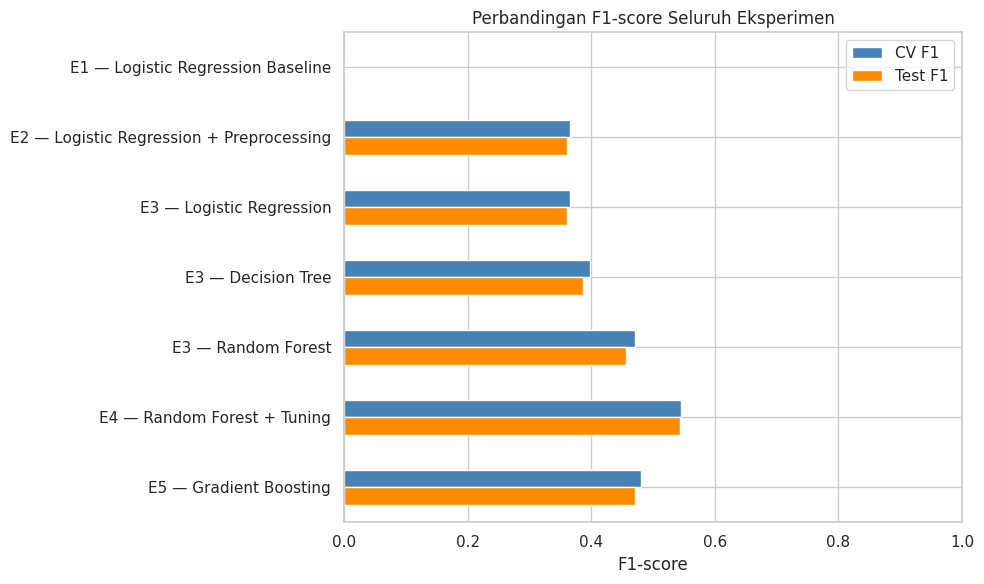

In [27]:
# SEL 17 — Grafik perbandingan F1-score

grafik = ringkasan[["CV F1", "Test F1"]].copy()

grafik.index = (
    "E" + ringkasan["Experiment"] + " — " + ringkasan["Model"]
)

ax = grafik.plot(
    kind="barh",
    figsize=(10, 6),
    color=["steelblue", "darkorange"]
)

ax.set_title("Perbandingan F1-score Seluruh Eksperimen")
ax.set_xlabel("F1-score")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Evaluasi Model Final

Model final dipilih berdasarkan CV F1 tertinggi. Classification report dan confusion matrix digunakan untuk melihat kemampuan model dalam mengenali nasabah gagal bayar serta jenis kesalahan prediksinya pada test set.

Model final berdasarkan CV F1 tertinggi: Random Forest + Tuning


,Experiment,Model,CV F1,CV F1 SD,Test Accuracy,Test Precision,Test Recall,Test F1,Sumber CV
0,4,Random Forest + Tuning,0.5444,0.0049,0.7863,0.5152,0.575,0.5434,Best CV dari GridSearchCV



CLASSIFICATION REPORT
               precision    recall  f1-score   support

Tidak Default     0.8752    0.8464    0.8605      4673
      Default     0.5152    0.5750    0.5434      1327

     accuracy                         0.7863      6000
    macro avg     0.6952    0.7107    0.7020      6000
 weighted avg     0.7956    0.7863    0.7904      6000



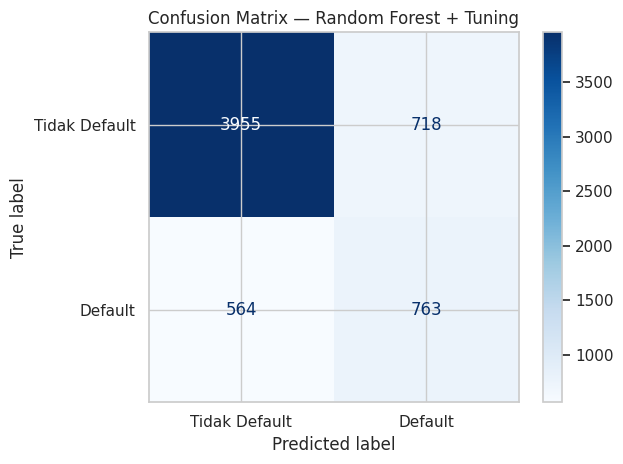

In [28]:
# SEL 18 — Model final dan evaluasi detail

# E3_LR tidak disertakan lagi karena identik dengan E2
kandidat_final = ["E1", "E2", "E3_DT", "E3_RF", "E4", "E5"]

kode_final = max(
    kandidat_final,
    key=lambda kode: hasil[kode]["CV F1"]
)

nama_final = hasil[kode_final]["Model"]
model_final = model_terlatih[kode_final]

print("Model final berdasarkan CV F1 tertinggi:", nama_final)
display(pd.DataFrame([hasil[kode_final]]).round(4))

# Menggunakan model yang sudah dilatih
prediksi_final = model_final.predict(X_test)

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        prediksi_final,
        labels=[0, 1],
        target_names=["Tidak Default", "Default"],
        digits=4,
        zero_division=0
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediksi_final,
    labels=[0, 1],
    display_labels=["Tidak Default", "Default"],
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix — {nama_final}")
plt.tight_layout()
plt.show()

**Interpretasi Evaluasi Model Final**

Random Forest hasil tuning memperoleh accuracy 78,63% dan F1-score kelas gagal bayar sebesar 0,5434. Model berhasil mengenali 763 dari 1.327 nasabah gagal bayar (recall 57,50%), tetapi masih melewatkan 564 nasabah. Selain itu, 3.955 nasabah tidak gagal bayar diprediksi dengan benar, sedangkan 718 keliru diprediksi gagal bayar. Model ini terbaik berdasarkan CV F1 dalam eksperimen, tetapi masih memiliki kesalahan deteksi yang perlu diperhatikan.

In [32]:
# SEL 19 — Menyimpan dan mengunduh hasil eksperimen

from pathlib import Path
import json
import shutil

folder = Path("hasil_uts")
folder.mkdir(exist_ok=True)

# Ringkasan seluruh eksperimen
ringkasan.to_csv(
    folder / "ringkasan_eksperimen.csv",
    index=True
)

# Hasil pencarian hyperparameter
hasil_grid[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params"
    ]
].sort_values("rank_test_score").to_csv(
    folder / "hasil_gridsearch.csv",
    index=False
)

# Classification report model final
laporan_final = classification_report(
    y_test,
    prediksi_final,
    labels=[0, 1],
    target_names=["Tidak Default", "Default"],
    output_dict=True,
    zero_division=0
)

pd.DataFrame(laporan_final).T.to_csv(
    folder / "classification_report_final.csv"
)

# Informasi eksperimen dan parameter terbaik
informasi = {
    "dataset": "UCI_Credit_Card.csv",
    "jumlah_training": len(X_train),
    "jumlah_testing": len(X_test),
    "random_state": SEED,
    "test_size": 0.20,
    "cv_folds": 5,
    "model_terbaik_experiment_3": nama_terbaik_e3,
    "parameter_terbaik": grid_search.best_params_,
    "best_cv_f1_tuning": float(grid_search.best_score_),
    "model_final": nama_final,
    "python_version": platform.python_version(),
    "sklearn_version": sklearn.__version__
}

with open(
    folder / "informasi_eksperimen.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(informasi, f, indent=2, ensure_ascii=False)

print("Parameter terbaik:")
for parameter, nilai in grid_search.best_params_.items():
    print(f"{parameter}: {nilai}")

# Gabungkan file menjadi ZIP
shutil.make_archive(
    "hasil_uts_prediksi_modern",
    "zip",
    root_dir=folder
)

print("\nHasil berhasil disimpan. Mengunduh ZIP...")
files.download("hasil_uts_prediksi_modern.zip")

Parameter terbaik:
model__class_weight: balanced
model__max_depth: 10
model__min_samples_leaf: 5
model__n_estimators: 200

Hasil berhasil disimpan. Mengunduh ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>